In [1]:
import import_helper
import_helper.add_models()
import model.conditions as ic
import model.simple_diffusion_degradation_model as sdd
import model.mesh_generation as meshgen
import model.intensity_analysis as analyse

import os
from fenics import *
from mshr import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'magma'
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"

### Simple diffusion and degradation model with fixed boundary conditions

The decay length scale $\gamma=\sqrt{k/D}$, where $\gamma \propto R$, $R$ the radius of circular micropattern in $\mu$ m.

From fitting TBXT data, the constant of proportionality is 0.03 

In [2]:
# radius of micropattern
R = 1000/2
print(R)
# decay length scale
gam = 0.03 * R
print(gam)

D = 0.1 # diffusion coefficient
d = (gam**2) * D  # degradation
print(d)

500.0
15.0
22.5


In [3]:
param = {"D":D, "d":d}

In [4]:
# initial conditions
u0 = ic.InitialConditionsRandom(noise=0.001, Ac=0.1, Ic=0.1)

# mesh generation
# circle
mesh = meshgen.circle(R=1, res=30)

## square
# square_length = np.sqrt(np.pi)
# mesh = meshgen.square(length=square_length, res=30)


# wavy stars
# wavy_star_length = 0.85 # to obtain area=pi
# area, mesh = meshgen.wavy_star(octagon_length=wavy_star_length)
# print(area)

## spiky stars
# star_length = np.sqrt(np.pi) / 2
# mesh = meshgen.four_pointed_star(length=star_length, res=30)

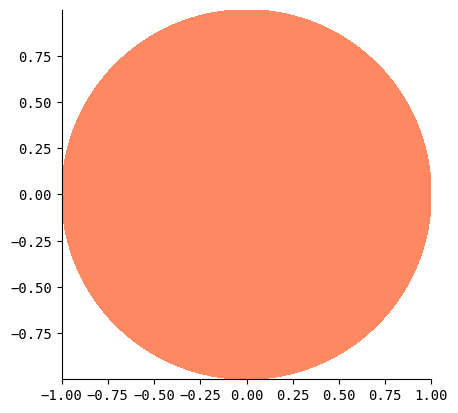

In [5]:
# make initial conditions
V = FunctionSpace(mesh, 'P', 1)
IC = Expression('0.1', degree=2)
u_0 = interpolate(IC, V)
plot(u_0)

In [6]:
Tend = 200
rd_steady_state = sdd.simple_diffusion_degradation(mesh, 
                                                   u_0,
                                                   T=Tend, 
                                                   dt=0.01,
                                                   param_set=param,
                                                   boundary_conditions="Mixed")
                                                #    save_file=f"paraview_files/circle_Aeq1.4_gamma196",
                                                #    save_step=0.01,
                                                #    check_production=True)

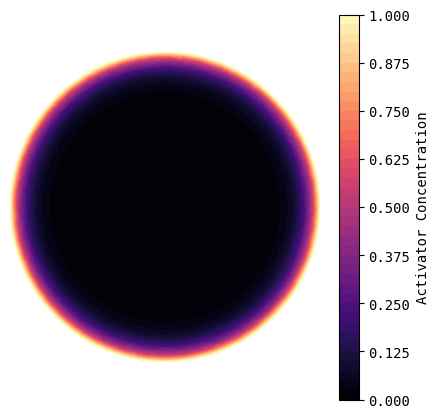

In [7]:
fig = plt.figure(figsize=(5,5))

# plt.subplot(1, 2, 1)
imA = plot(rd_steady_state, cmap="magma")
imA.set_clim(0, 1)
plt.axis("off")
plt.colorbar(imA, label="Activator Concentration")
fig.savefig("rd_model_D1000_T200.png", transparent=True)